# Regressão do desempenho no ENEM

Este notebook prevê a média geral (`media_geral`) com modelos de regressão. O `Pipeline` garante que a imputação e, quando necessária, a padronização sejam ajustadas novamente usando apenas os dados de treino de cada fold. O `cross_validate` treina uma cópia independente do pipeline em cada divisão.

O `Pipeline` garante que a imputação e, quando necessária, a padronização sejam ajustadas novamente usando apenas o treino de cada fold. O `cross_validate` cria e treina uma cópia independente desse pipeline em cada divisão.

In [2]:
# importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

## Base, atributos e validação

O CSV contém atributos numéricos e a nota média (`media_geral`), que será o alvo. Os atributos usados para prever a nota são separados em `X`, enquanto a média contínua fica em `y_regressao`.

A base ainda possui valores ausentes. Por isso, `SimpleImputer` será incluído no pipeline de cada modelo. Ele calculará uma mediana diferente em cada fold, sempre a partir da parte usada para treinamento.

In [3]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC_PARA_REGRESSAO.csv")
df_acre.head()

,TP_FAIXA_ETARIA_1,TP_FAIXA_ETARIA_2,TP_FAIXA_ETARIA_3,TP_FAIXA_ETARIA_4,TP_FAIXA_ETARIA_5,TP_FAIXA_ETARIA_6,TP_FAIXA_ETARIA_7,TP_FAIXA_ETARIA_8,TP_FAIXA_ETARIA_9,TP_FAIXA_ETARIA_10,...,Q022_D,Q022_E,Q023_B,Q024_A,Q024_B,Q024_C,Q024_D,Q024_E,Q025_B,media_geral
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,391.10
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,393.16
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,648.84
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,435.68
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,548.14


In [4]:
X = df_acre.drop(columns=["media_geral"]).copy()
y_regressao = df_acre["media_geral"]

assert y_regressao.notna().all(), "Existem notas médias ausentes."
assert all(pd.api.types.is_numeric_dtype(tipo) for tipo in X.dtypes)
assert not np.isinf(X.to_numpy()).any()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_regressao,
    test_size=0.2,
    random_state=42,
)

cv_regressao = KFold(
    n_splits=10, 
    shuffle=True, 
    random_state=42
)

## 1. Regressão Linear

In [5]:
modelo_regressao_linear = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", LinearRegression()),
])

resultado_regressao_linear = cross_validate(
    modelo_regressao_linear,
    X,
    y_regressao,
    cv=cv_regressao,
    scoring=[
        'r2',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
    ],
    return_train_score=False,
)

df_result = pd.DataFrame(resultado_regressao_linear).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result['MSE'] = -df_result['MSE']
df_result['RMSE'] = -df_result['RMSE']
df_result['MAE'] = -df_result['MAE']
df_result.index = [f'Fold {i+1}' for i in range(10)]
df_result.loc['Média'] = df_result.mean()
df_result.loc['Desvio Padrão'] = df_result.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA — Regressão Linear')
print('═' * 50)
print(df_result.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA — Regressão Linear
══════════════════════════════════════════════════
                  R2       MSE    RMSE     MAE
Fold 1        0.2809 5194.5079 72.0729 56.8974
Fold 2        0.2752 5592.2262 74.7812 58.1050
Fold 3        0.2993 5487.3382 74.0766 57.8838
Fold 4        0.2850 6119.3262 78.2261 61.7838
Fold 5        0.2585 5493.3819 74.1174 57.7089
Fold 6        0.2778 5586.0839 74.7401 58.5426
Fold 7        0.2626 5561.3754 74.5746 58.3319
Fold 8        0.2558 6004.4821 77.4886 61.0849
Fold 9        0.2471 5242.7323 72.4067 57.3440
Fold 10       0.2649 5178.0994 71.9590 56.3057
Média         0.2707 5545.9553 74.4443 58.3988
Desvio Padrão 0.0157  316.2220  2.1077  1.7408


In [6]:
modelo_teste = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", LinearRegression()),
])
modelo_teste.fit(X_train, y_train)
y_pred_teste_lr = modelo_teste.predict(X_test)

print('COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — Regressão Linear')
print('═' * 59)
for i in range(10):
    print(f"{y_test.iloc[i]:.2f}|{y_pred_teste_lr[i]:.2f}")

COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — Regressão Linear
═══════════════════════════════════════════════════════════
342.10|406.87
497.84|486.88
526.02|430.05
475.96|526.68
445.92|442.77
590.22|561.83
549.08|499.23
563.10|456.60
513.76|496.79
450.82|488.97


## 2. Árvore de Regressão

In [7]:
modelo_arvore_regressao = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", DecisionTreeRegressor(max_depth=5, random_state=42)),
])

resultado_arvore_regressao = cross_validate(
    modelo_arvore_regressao,
    X,
    y_regressao,
    cv=cv_regressao,
    scoring=[
        'r2',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
    ],
    return_train_score=False,
)

df_result_arvore_regressao = pd.DataFrame(resultado_arvore_regressao).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result_arvore_regressao.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result_arvore_regressao['MSE'] = -df_result_arvore_regressao['MSE']
df_result_arvore_regressao['RMSE'] = -df_result_arvore_regressao['RMSE']
df_result_arvore_regressao['MAE'] = -df_result_arvore_regressao['MAE']
df_result_arvore_regressao.index = [f'Fold {i+1}' for i in range(10)]
df_result_arvore_regressao.loc['Média'] = df_result_arvore_regressao.mean()
df_result_arvore_regressao.loc['Desvio Padrão'] = df_result_arvore_regressao.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA — Árvore de Regressão')
print('═' * 53)
print(df_result_arvore_regressao.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA — Árvore de Regressão
═════════════════════════════════════════════════════
                  R2       MSE    RMSE     MAE
Fold 1        0.2044 5747.4675 75.8121 60.1008
Fold 2        0.2156 6052.2565 77.7962 60.7372
Fold 3        0.2391 5959.0731 77.1950 60.2315
Fold 4        0.2130 6735.0477 82.0673 64.4354
Fold 5        0.2056 5885.2367 76.7153 59.9388
Fold 6        0.2295 5959.7998 77.1997 60.6812
Fold 7        0.2006 6028.7254 77.6449 60.7424
Fold 8        0.1819 6600.8999 81.2459 63.3107
Fold 9        0.2013 5561.5733 74.5760 59.2231
Fold 10       0.1982 5648.2869 75.1551 59.1526
Média         0.2089 6017.8367 77.5408 60.8554
Desvio Padrão 0.0163  379.7521  2.4194  1.7083


In [38]:
modelo_teste = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", DecisionTreeRegressor(max_depth=5, random_state=42)),
])
modelo_teste.fit(X_train, y_train)
y_pred_teste_dt = modelo_teste.predict(X_test)

print('COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — Árvore de Regressão')
print('═' * 62)
for i in range(10):
    print(f"{y_test.iloc[i]:.2f}|{y_pred_teste_dt[i]:.2f}")

COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — Árvore de Regressão
══════════════════════════════════════════════════════════════
342.10|448.37
497.84|491.05
526.02|474.94
475.96|529.38
445.92|474.94
590.22|558.06
549.08|578.06
563.10|474.94
513.76|476.46
450.82|474.94


## 3. KNN Regressor

O KNN calcula distâncias. Por isso, depois da imputação, os atributos são padronizados dentro de cada fold.

In [9]:
modelo_knn_regressao = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", KNeighborsRegressor(n_neighbors=5, weights='distance')),
])

resultado_knn_regressao = cross_validate(
    modelo_knn_regressao,
    X,
    y_regressao,
    cv=cv_regressao,
    scoring=[
        'r2',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
    ],
    return_train_score=False,
)

df_result_knn_regressao = pd.DataFrame(resultado_knn_regressao).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result_knn_regressao.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result_knn_regressao['MSE'] = -df_result_knn_regressao['MSE']
df_result_knn_regressao['RMSE'] = -df_result_knn_regressao['RMSE']
df_result_knn_regressao['MAE'] = -df_result_knn_regressao['MAE']
df_result_knn_regressao.index = [f'Fold {i+1}' for i in range(10)]
df_result_knn_regressao.loc['Média'] = df_result_knn_regressao.mean()
df_result_knn_regressao.loc['Desvio Padrão'] = df_result_knn_regressao.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA — KNN Regressor')
print('═' * 47)
print(df_result_knn_regressao.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA — KNN Regressor
═══════════════════════════════════════════════
                  R2       MSE    RMSE     MAE
Fold 1        0.0998 6503.1027 80.6418 63.9571
Fold 2        0.1313 6702.2759 81.8674 65.1266
Fold 3        0.1643 6544.4976 80.8981 64.0720
Fold 4        0.1181 7547.2299 86.8748 69.1770
Fold 5        0.0815 6804.7283 82.4908 64.8836
Fold 6        0.1079 6900.9358 83.0719 64.5285
Fold 7        0.0910 6855.2196 82.7963 65.3386
Fold 8        0.1052 7220.0549 84.9709 66.5925
Fold 9        0.0731 6454.3428 80.3389 63.0724
Fold 10       0.0932 6387.5155 79.9219 62.8500
Média         0.1065 6791.9903 82.3873 64.9598
Desvio Padrão 0.0265  365.1512  2.1926  1.8445


In [10]:
modelo_teste = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", KNeighborsRegressor(n_neighbors=5, weights='distance')),
])
modelo_teste.fit(X_train, y_train)
y_pred_teste_knn = modelo_teste.predict(X_test)

print('COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — KNN Regressor')
print('═' * 56)
for i in range(10):
    print(f"{y_test.iloc[i]:.2f}|{y_pred_teste_knn[i]:.2f}")

COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — KNN Regressor
════════════════════════════════════════════════════════
342.10|426.16
497.84|508.38
526.02|485.26
475.96|472.90
445.92|470.06
590.22|550.30
549.08|445.43
563.10|458.45
513.76|508.30
450.82|477.85


## 4. SVR

o SVR busca uma função que se ajuste aos dados contínuos.

In [11]:
modelo_svr = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", SVR(kernel="rbf", C=1.0)),
])

resultado_svr = cross_validate(
    modelo_svr,
    X,
    y_regressao,
    cv=cv_regressao,
    scoring=[
        'r2',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
    ],
    return_train_score=False,
)

df_result_svr = pd.DataFrame(resultado_svr).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result_svr.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result_svr['MSE'] = -df_result_svr['MSE']
df_result_svr['RMSE'] = -df_result_svr['RMSE']
df_result_svr['MAE'] = -df_result_svr['MAE']
df_result_svr.index = [f'Fold {i+1}' for i in range(10)]
df_result_svr.loc['Média'] = df_result_svr.mean()
df_result_svr.loc['Desvio Padrão'] = df_result_svr.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA — SVR')
print('═' * 46)
print(df_result_svr.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA — SVR
══════════════════════════════════════════════
                  R2       MSE    RMSE     MAE
Fold 1        0.1851 5887.0451 76.7271 60.8699
Fold 2        0.1896 6252.7772 79.0745 62.0526
Fold 3        0.1908 6337.0376 79.6055 63.0385
Fold 4        0.1748 7061.9049 84.0351 67.0014
Fold 5        0.1767 6099.2115 78.0974 61.4872
Fold 6        0.1861 6295.9470 79.3470 62.6108
Fold 7        0.1792 6189.8530 78.6756 62.5007
Fold 8        0.1481 6873.4887 82.9065 65.3785
Fold 9        0.1702 5778.6734 76.0176 60.6790
Fold 10       0.1942 5676.5656 75.3430 59.6356
Média         0.1795 6245.2504 78.9829 62.5254
Desvio Padrão 0.0134  443.0279  2.7780  2.2173


In [ ]:
modelo_teste = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", SVR(kernel="rbf", C=1.0)),
])

modelo_teste.fit(X_train, y_train)
y_pred_teste_svr = modelo_teste.predict(X_test)

print('COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — S' \
'VR')
print('═' * 46)
print('Nota Real | Nota Prevista')
for i in range(10):
    print(f"{y_test.iloc[i]:.2f}|{y_pred_teste_svr[i]:.2f}")

COMPARAÇÃO ENTRE NOTAS REAIS E PREVISTAS — SVR
══════════════════════════════════════════════
Nota Real | Nota Prevista
342.10|487.53
497.84|518.08
526.02|511.34
475.96|508.47
445.92|492.74
590.22|548.35
549.08|524.27
563.10|471.42
513.76|507.22
450.82|488.44


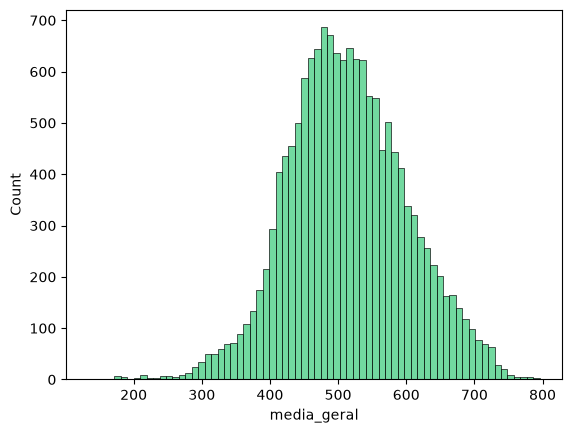

In [45]:
import matplotlib.pyplot as plt
sns.histplot(df_acre['media_geral'], color='#43CD80')
plt.show()

In [40]:
df_comparacao = pd.DataFrame({
    "Nota Real": y_test.iloc[:10].values,
    "Regressão Linear": y_pred_teste_lr[:10],
    "Árvore de Regressão": y_pred_teste_dt[:10],
    "KNN Regressor": y_pred_teste_knn[:10],
    "SVR": y_pred_teste_svr[:10],
})

display(df_comparacao.round(2))

,Nota Real,Regressão Linear,Árvore de Regressão,KNN Regressor,SVR
0,342.10,406.87,448.37,426.16,487.53
1,497.84,486.88,491.05,508.38,518.08
2,526.02,430.05,474.94,485.26,511.34
3,475.96,526.68,529.38,472.90,508.47
4,445.92,442.77,474.94,470.06,492.74
5,590.22,561.83,558.06,550.30,548.35
6,549.08,499.23,578.06,445.43,524.27
7,563.10,456.60,474.94,458.45,471.42
8,513.76,496.79,476.46,508.30,507.22
9,450.82,488.97,474.94,477.85,488.44


## Comparação dos modelos executados

Os modelos são avaliados por validação cruzada usando R², erro quadrático médio (MSE), raiz do erro quadrático médio (RMSE) e erro absoluto médio (MAE).